In [1]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")
import pandas as pd
import Scene
import BrainRegion as BR 
import IONData 
iondata = IONData.IONData()

isosampleid = iondata.getSampleInfo(projectID='ISO')
len(isosampleid)


221

In [4]:
import BrainRegion as BR 
import numpy as np
br = BR.BrainRegion()
br.praseJson()

count=0
neuronRegion={}
MBneurons=[]
for sample in isosampleid:

    sampleid =sample['fMOST_id']
    neurons = iondata.getNeuronListBySampleID(str(sampleid))
    for neuron in neurons:
        prop = iondata.getNeuronPropertyByID(neuron['sampleid'],neuron['name'])
        if prop['somaregion'] not in neuronRegion.keys():
            neuronRegion[prop['somaregion']]=[]
        neuronRegion[prop['somaregion']].append(neuron)
        brproperty=BR.RegionProperty(copy.deepcopy(br))
        brproperty.setProperty(prop['projectregion'])
        regionsum = brproperty.getSumProperty('HB')
        if regionsum>0:
            MBneurons.append(neuron)


In [5]:
print(len(MBneurons))
for neuron in MBneurons:
    neuron['mirror']=0
Scene.createScene(neuronlist=MBneurons,filename='../resource/scene/ISO2HBneurons.nv')

1484


## load neuron list

In [26]:
ISO2HBneurons=Scene.scene2List(filename='../resource/scene/ISO2HBneurons.nv')
ISO2MBneurons=Scene.scene2List(filename='../resource/scene/ISO2MBneurons.nv')
print(ISO2HBneurons)

[{'color': {'r': '255', 'g': '107', 'b': '134'}, 'mirror': 0, 'name': '009.swc', 'sampleid': '212064'}, {'color': {'r': '32', 'g': '112', 'b': '172'}, 'mirror': 0, 'name': '011.swc', 'sampleid': '212064'}, {'color': {'r': '152', 'g': '1', 'b': '146'}, 'mirror': 0, 'name': '012.swc', 'sampleid': '212067'}, {'color': {'r': '213', 'g': '66', 'b': '12'}, 'mirror': 0, 'name': '003.swc', 'sampleid': '212069'}, {'color': {'r': '81', 'g': '173', 'b': '185'}, 'mirror': 0, 'name': '020.swc', 'sampleid': '212070'}, {'color': {'r': '106', 'g': '173', 'b': '30'}, 'mirror': 0, 'name': '013.swc', 'sampleid': '212072'}, {'color': {'r': '135', 'g': '5', 'b': '193'}, 'mirror': 0, 'name': '012.swc', 'sampleid': '212073'}, {'color': {'r': '254', 'g': '82', 'b': '112'}, 'mirror': 0, 'name': '013.swc', 'sampleid': '212073'}, {'color': {'r': '86', 'g': '161', 'b': '65'}, 'mirror': 0, 'name': '002.swc', 'sampleid': '212074'}, {'color': {'r': '230', 'g': '148', 'b': '127'}, 'mirror': 0, 'name': '019.swc', 'sam

In [11]:
br = BR.BrainRegion()
br.praseJson()
MBregions = br.getRegionList('MB')
# print(MBregions)
hbregions=[ ['NLL', 612],  ['PSV', 7], ['PB', 867],  ['POR', 122], ['SOCm', 105], ['SOCl', 114],  ['B', 280], ['DTN', 880], ['PDTg', 599626927], ['PCG', 898], ['PG', 931],
            ['PRNc', 1093], ['SG', 318], ['SUT', 534], ['TRN', 574], ['V', 621], ['P5', 549009215],  ['PC5', 549009223], ['I5', 549009227], 
            ['CS', 679],['LC', 147], ['LDT', 162], ['NI', 604], ['PRNr', 146], ['RPO', 238], ['SLC', 350], ['SLD', 358],
            ['AP', 207], ['DCO', 96], ['VCO', 101], ['CU', 711], ['GR', 1039], ['ECU', 903], ['NTB', 642], ['NTS', 651],['SPVC', 429],['SPVO', 445], ['Pa5', 589508451], 
            ['VI', 653], ['VII', 661], ['AMB', 135], ['DMX', 839],  ['GRN', 1048], ['ICB', 372], ['IO', 83], ['IRN', 136], ['LIN', 203], ['LRN', 235], 
            ['MARN', 307], ['MDRN', 395], ['PARN', 852], ['PAS', 859], ['PGRN', 938], ['PHY', 154],  ['PPY', 1069], ['VNC', 701],  ['x', 765], ['XII', 773], ['y', 781],  
            ['RM', 206], ['RPA', 230], ['RO', 222]]
mbregions=[['SCop', 851], ['SCsg', 842], ['SCzo', 834], ['ICc', 811], ['ICd', 820], ['ICe', 828], ['NB', 580], ['SAG', 271], ['PBG', 874], ['MEV', 460], ['SCO', 599626923], 
           ['SNr', 381], ['VTA', 749], ['PN', 607344830], ['RR', 246], ['MRN', 128], ['SCm', 294], ['PAG', 795], ['PRT', 1100],  ['CUN', 616], ['III', 35],  ['EW', 975], ['IV', 115], ['Pa4', 606826663], ['VTN', 757], ['AT', 231], ['LT', 66], ['DT', 75], ['MT', 58],  
           ['SNc', 374], ['PPN', 1052], ['IF', 12], ['IPN', 100], ['RL', 197], ['CLI', 591], ['DR', 872]]

In [14]:
propmat=[]
regionpropmat=[]
regionprop=[]
propmat2=[]
for neuron in ISO2HBneurons:

    property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
    brproperty=BR.RegionProperty(copy.deepcopy(br))
    brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
    brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
    brproperty.setProperty(property['projectregion'])
    brpropertyLeft.setProperty(property['projectleftregion'])
    brpropertyRight.setProperty(property['projectrightregion'])
    prop=[]
    for targetRegion in hbregions:
        regionsum = brproperty.getSumProperty(targetRegion[0])
        regionleft = brpropertyLeft.getSumProperty(targetRegion[0])
        regionright = brpropertyRight.getSumProperty(targetRegion[0])
        ipsi=0
        contra=0
        if property['somapoint'][2]<5700:
            ipsi=regionleft
            contra=regionright
        else:
            ipsi=regionright
            contra=regionleft
        prop.append(ipsi)
    propmat.append(prop)
    propmat2.append(prop)


NameError: name 'np' is not defined

In [15]:
import numpy as np
if len(propmat2)>0:
    temp = np.array(propmat2)
    regionprop = temp.sum(0)
    regionpropmat.append(list(regionprop))

In [28]:
propmat2

[[0,
  0,
  0,
  0,
  118.88488,
  0,
  0,
  0,
  0,
  6.625943,
  335.56134,
  4735.241211,
  0,
  0,
  7449.320312,
  0,
  0,
  0,
  0,
  2121.470459,
  0,
  58.383934,
  451.866333,
  6416.124023,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  66.953064,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  518.332581,
  0,
  0,
  0,
  0,
  0,
  1050.242432,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  107.464134,
  0,
  0],
 [0,
  0,
  0,
  0,
  0,
  0,
  2.919098,
  0,
  0,
  1789.694092,
  136.726715,
  500.917603,
  0,
  0,
  606.501343,
  0,
  351.620575,
  0,
  0,
  0,
  0,
  1256.465942,
  0,
  2420.906494,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1036.546509,
  0,
  0,
  0,
  874.241821,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,


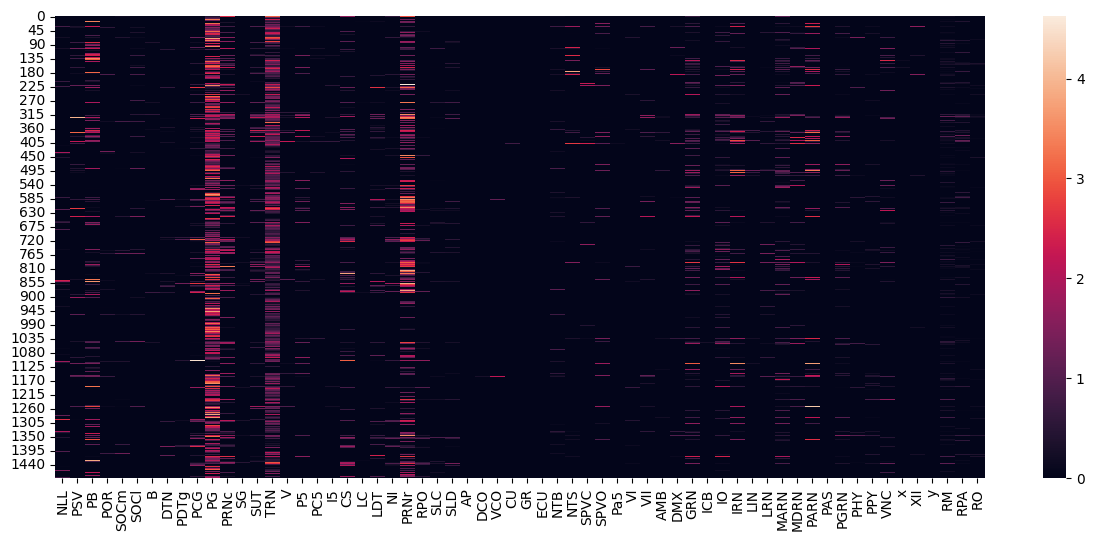

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
column=[]
for region in hbregions:
    column.append(region[0])
mat = np.log2(np.array(propmat2)/1000.0+1)
df = pd.DataFrame(mat,columns=column)
plt.figure(figsize=(15,6))
sns.heatmap(df)
plt.show()

In [2]:
isoneurons=[]
sum=0
print(isosampleid[0])
for sample in isosampleid:
    sum+=sample['tracing_cell_number']
    print(sample['fMOST_id'],sample['tracing_cell_number'],sample['transgenic_line'])
    # isoneurons+=iondata.getNeuronListBySampleID(sample)
print(sum)

{'published': None, 'project_id': 'ISO', 'fMOST_id': 212064, 'sample_id': 'ISO_1_1#', 'spicies': 'mouse', 'gender': 0, 'transgenic_line': 'C57BL/6J', 'generation_method': None, 'public_repository': None, 'public_repository_stock': None, 'repository_strain_name': None, 'age': None, 'injection_time': '2021-10-07T16:00:00.000Z', 'ample_delivery_time': 48, 'injection_region': '', 'injection_structure': 'MOp5;MOp6a;MOs5;MOs6a;SSp-bfd4;SSp-bfd6a;SSp-n5;SSs5;SSs6a;scwm;', 'injection_coordinates': None, 'injection_virus': '(AAV2/8-hSyn-cre-wpre( 1:1.5w 30 nl) +AAV2/8-CAG-FLEX-EGFP-WPRE-pA), 1:1.5w, 6weeks, wild type', 'injection_volume': None, 'injection_tamoxifen': None, 'putative_labeled_cell_number': None, 'tracing_cell_number': 17, 'lab_name': '孙衍刚', 'author': None, 'injection_region_id': 'undefined;', 'injection_structure_id': '648;844;767;1021;1047;1038;702;1090;862;484682512;'}
212064 17 C57BL/6J
212258 63 C57BL/6J
212065 24 C57BL/6J
212067 21 C57BL/6J
212069 11 C57BL/6J
212070 26 C57BL

In [8]:
import sys
import glfw
import OpenGL.GL as gl
import RenderGL,GeometryAdapter
render = RenderGL.RenderGL(renderModel=0)
# render.setBackgroundColor([1,1,1])
render.setLineWidth(4.0)
ga = GeometryAdapter.GeometryAdapter()
index=0
for sample in isosampleid:
    somas = iondata.getSoma(sample['fMOST_id'])
    for soma in somas:
        z=soma['somaz']
        if z>5700:
            z=11400-z
        ga.geometry.addPoint([soma['somax'],soma['somay'],z],[1.0,1.0,1.0])
        ga.geometry.addIndex(index)
        index+=1



ga.geometry.drawModel='points'
render.setPointSize(4)
render.addGeometry(ga.geometry)
# render.setClip(True)
# render.savepng('../resource/test3.png')
render.run()